# 01 · Quickstart / 快速開始

The fastest path to your first significance plot.
最快的路徑：跑出第一張顯著性檢定圖。

**Goal**: mix a 1/64-period sine wave with white noise, decompose with EMD, and find which IMFs are signal.

**目標**：把週期 64 的正弦波與白雜訊混合，用 EMD 分解，找出哪些 IMF 是真實訊號。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

from emdsig import (
    compute_et,
    chi2_confidence_bounds,
    calibrate_intercept,
    plot_significance,
)

rng = np.random.default_rng(42)

## 1. Synthesize a signal + noise mixture / 合成訊號+雜訊

/raid/jupyter-yzhiwei22.md12/miniconda3/envs/Lab/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/raid/jupyter-yzhiwei22.md12/miniconda3/envs/Lab/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/raid/jupyter-yzhiwei22.md12/miniconda3/envs/Lab/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35338 (\N{CJK UNIFIED IDEOGRAPH-8A0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/raid/jupyter-yzhiwei22.md12/miniconda3/envs/Lab/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34399 (\N{CJK UNIFIED IDEOGRAPH-865F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


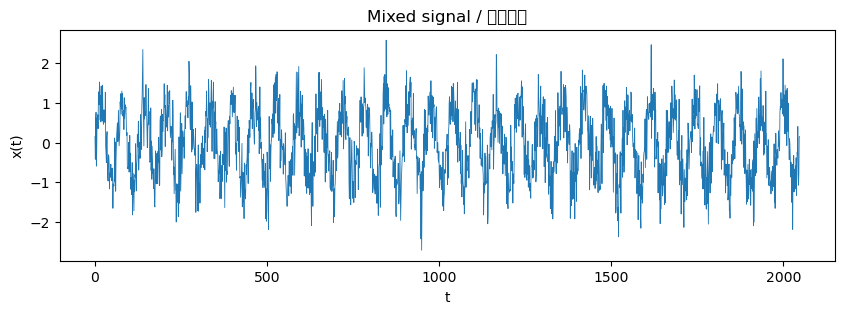

In [2]:
N = 2048
t = np.arange(N)
signal = np.sin(2 * np.pi * t / 64)
noise = 0.5 * rng.standard_normal(N)
x = signal + noise

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, x, lw=0.6)
ax.set_title('Mixed signal / 混合訊號')
ax.set_xlabel('t'); ax.set_ylabel('x(t)')
plt.show()

## 2. EMD decomposition / EMD 分解

number of IMFs: 8


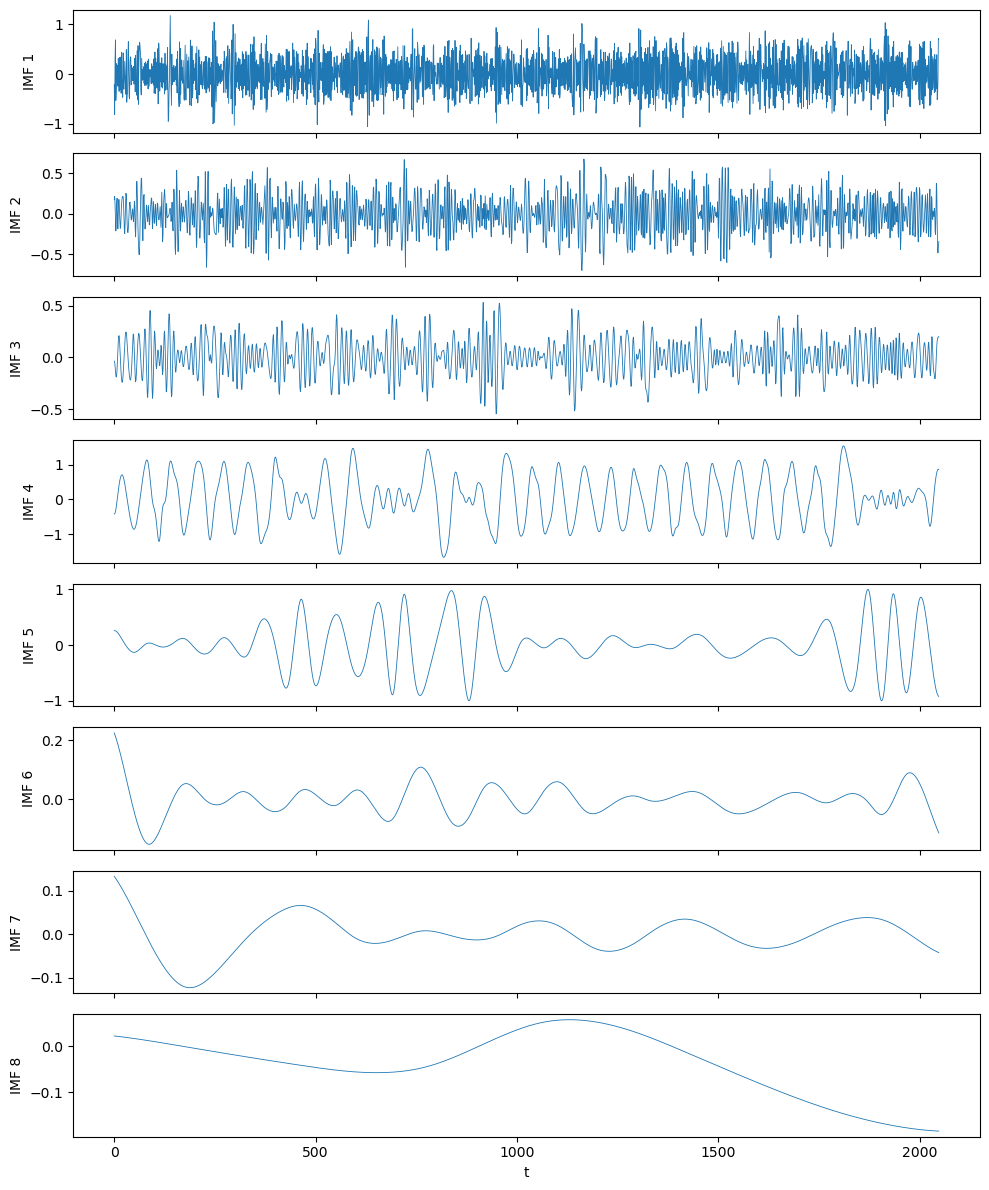

In [3]:
imfs = EMD().emd(x)
print(f'number of IMFs: {imfs.shape[0]}')

fig, axes = plt.subplots(imfs.shape[0], 1, figsize=(10, 1.5 * imfs.shape[0]), sharex=True)
for i, (ax, imf) in enumerate(zip(axes, imfs)):
    ax.plot(imf, lw=0.6)
    ax.set_ylabel(f'IMF {i+1}')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()

## 3. Compute (E, T) for each IMF / 計算每個 IMF 的能量與週期

In [4]:
E, T = compute_et(imfs, trim_ratio=0.05)
valid = ~np.isnan(T)
ln_E = np.log(E[valid])
ln_T = np.log(T[valid])
for i, (lT, lE) in enumerate(zip(ln_T, ln_E)):
    print(f'IMF {i+1}: ln(T)={lT:.3f}  ln(E)={lE:.3f}')

IMF 1: ln(T)=0.350  ln(E)=-1.846
IMF 2: ln(T)=1.072  ln(E)=-3.007
IMF 3: ln(T)=1.753  ln(E)=-3.578
IMF 4: ln(T)=3.206  ln(E)=-0.674
IMF 5: ln(T)=3.911  ln(E)=-1.899
IMF 6: ln(T)=4.406  ln(E)=-6.562
IMF 7: ln(T)=5.227  ln(E)=-6.413
IMF 8: ln(T)=6.526  ln(E)=-5.353


## 4. Significance test — closed-form chi-squared / 閉式卡方檢定

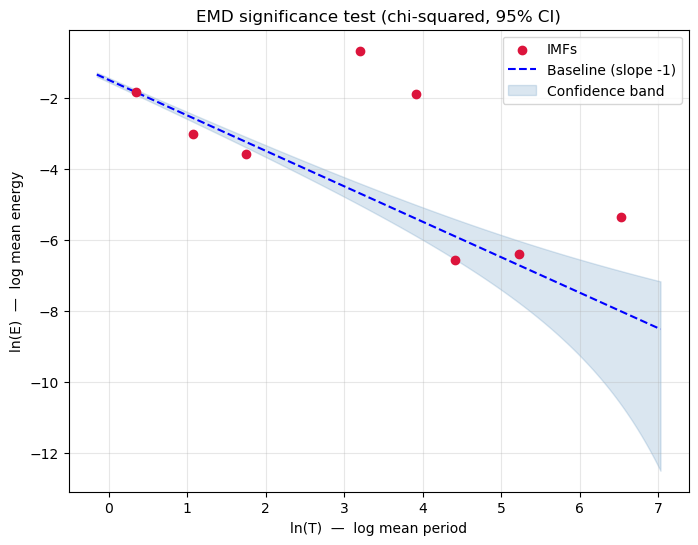

In [5]:
c = calibrate_intercept(ln_T[0], ln_E[0])   # anchor on c_1
grid = np.linspace(ln_T.min() - 0.5, ln_T.max() + 0.5, 200)
lo, hi = chi2_confidence_bounds(grid, N=N, alpha=0.05, baseline_intercept=c)

ax = plot_significance(
    ln_T, ln_E,
    bounds=(grid, lo, hi),
    baseline_intercept=c,
    title='EMD significance test (chi-squared, 95% CI)',
)
plt.show()

## 5. Interpretation / 判讀

The IMF whose period is close to 64 (ln(64) ≈ 4.16) should sit above the upper bound — that is the 1/64 sine component we injected. Other IMFs fall within the band and should be treated as noise.

週期接近 64（ln(64) ≈ 4.16）的那個 IMF 應當落在信賴上限之上——那就是我們注入的 1/64 正弦分量。其他 IMF 位於信賴帶之內，應視為雜訊。